In [1]:
from tqdm import tqdm
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem import Draw
from rdkit import Chem
RDLogger.DisableLog("rdApp.*")
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, matthews_corrcoef, classification_report
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.nn import GINConv
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_curve, auc


df_train = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_train.csv')
df_val = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_val.csv')
df_test = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_test.csv')
# herg_data = pd.read_csv("/home/f087s426/Research/Masters_Thesis/herg/hERG_IC50.csv")
# herg_data=herg_data[['Smiles','pChEMBL Value']]
# herg_data=herg_data.dropna()
# herg_data['label'] = herg_data['pChEMBL Value'].apply(lambda x: 1 if x >= 6.5 else 0)
# herg_data['group']= 1
# herg_data['smiles_standarized']=herg_data['Smiles']
# herg_data=herg_data[['smiles_standarized','label','group']]


df=pd.concat([df_train,df_val,df_test])
df['smiles'] = df['smiles_standarized'].apply(lambda s: s.replace('\n', ''))
print(len(df))

test_df = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/paper_valid_data.csv')
#test_df['smiles'] = test_df['smiles_standarized'].apply(lambda s: s.replace('\n', ''))
test_df['smiles'] = test_df['SMILES'].apply(lambda s: s.replace('\n', ''))


def one_hot_encoding(x, permitted_list):
    """
    Maps input elements x which are not in the permitted list to the last element
    of the permitted list.
    """
    if x not in permitted_list:
        x = permitted_list[-1]
    binary_encoding = [int(boolean_value) for boolean_value in list(map(lambda s: x == s, permitted_list))]
    return binary_encoding

def get_atom_features(atom, use_chirality=True):
    # Define a simplified list of atom types
    permitted_atom_types = ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'Dy', 'Unknown']
    atom_type = atom.GetSymbol() if atom.GetSymbol() in permitted_atom_types else 'Unknown'
    atom_type_enc = one_hot_encoding(atom_type, permitted_atom_types)

    # Consider only the most impactful features: atom degree and whether the atom is in a ring
    atom_degree = one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 'MoreThanFour'])
    is_in_ring = [int(atom.IsInRing())]

    # Optionally include chirality
    if use_chirality:
        chirality_enc = one_hot_encoding(str(atom.GetChiralTag()),
                                         ["CHI_UNSPECIFIED", "CHI_TETRAHEDRAL_CW", "CHI_TETRAHEDRAL_CCW", "CHI_OTHER"])
        atom_features = atom_type_enc + atom_degree + is_in_ring + chirality_enc
    else:
        atom_features = atom_type_enc + atom_degree + is_in_ring

    return np.array(atom_features, dtype=np.float32)

def get_bond_features(bond):
    # Simplified list of bond types
    permitted_bond_types = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE, Chem.rdchem.BondType.TRIPLE,
                            Chem.rdchem.BondType.AROMATIC, 'Unknown']
    bond_type = bond.GetBondType() if bond.GetBondType() in permitted_bond_types else 'Unknown'

    # Features: Bond type, Is in a ring
    features = one_hot_encoding(bond_type, permitted_bond_types) \
               + [int(bond.IsInRing())]

    return np.array(features, dtype=np.float32)

def create_pytorch_geometric_graph_data_list_from_smiles_and_labels(x_smiles, y):
    data_list = []

    for index, smiles in enumerate(x_smiles):
        mol = Chem.MolFromSmiles(smiles)

        if not mol:  # Skip invalid SMILES strings
            continue

        # Node features
        atom_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
        x = torch.tensor(atom_features, dtype=torch.float)

        # Edge features
        edge_index = []
        edge_features = []
        for bond in mol.GetBonds():
            start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edge_index += [(start, end), (end, start)]  # Undirected graph
            bond_feature = get_bond_features(bond)
            edge_features += [bond_feature, bond_feature]  # Same features in both directions

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)

        # Creating the Data object
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.y = torch.tensor(y[index], dtype=torch.float)
        data.smiles = x_smiles[index] 
        data_list.append(data)

    return data_list

def featurize_data_in_batches(smiles_list, labels_list, batch_size):
    data_list = []
    # Define tqdm progress bar
    pbar = tqdm(total=len(smiles_list), desc="Featurizing data")
    for i in range(0, len(smiles_list), batch_size):
        smiles_batch = smiles_list[i:i + batch_size]
        labels_batch = labels_list[i:i + batch_size]

        batch_data_list = create_pytorch_geometric_graph_data_list_from_smiles_and_labels(smiles_batch,labels_batch)
        data_list.extend(batch_data_list)
        pbar.update(len(smiles_batch))

    pbar.close()
    return data_list

batch_size = 2
featurized_data = featurize_data_in_batches(df.smiles.tolist(),df.label.tolist(), batch_size)
test_data = featurize_data_in_batches(test_df.smiles.tolist(), test_df.label.tolist(), batch_size)

20728


Featurizing data:   0%|                               | 0/20728 [00:00<?, ?it/s]/tmp/ipykernel_81402/2319730809.py:104: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  x = torch.tensor(atom_features, dtype=torch.float)
Featurizing data: 100%|█████████████████████| 100/100 [00:00<00:00, 1561.88it/s]


In [3]:
df.label.value_counts()

label
1.0    12903
0.0     7825
Name: count, dtype: int64

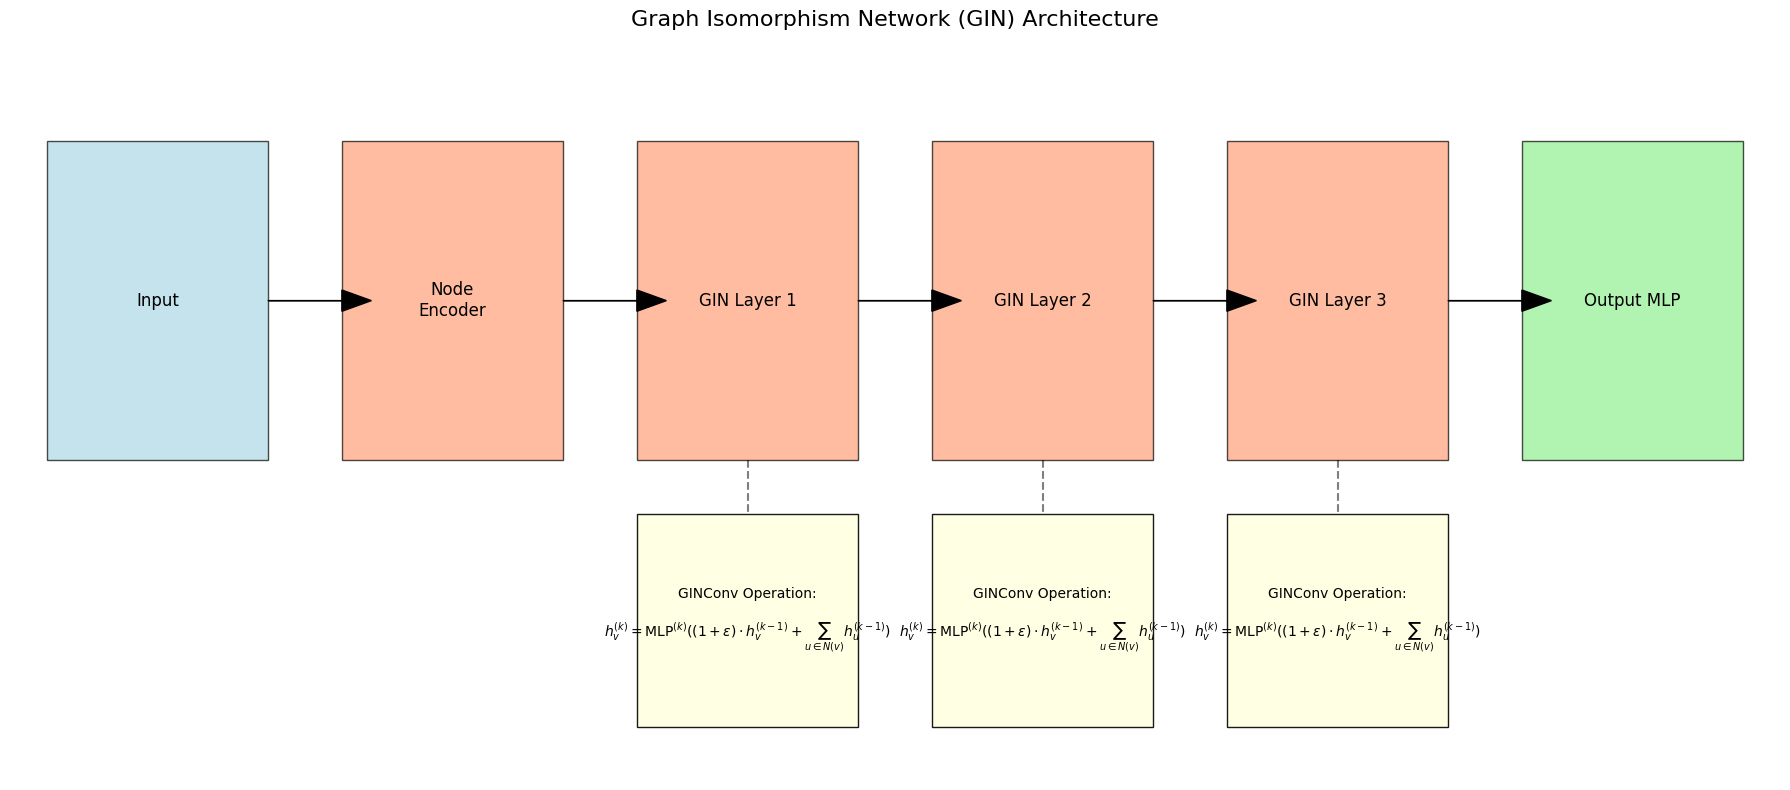

In [11]:
class MLP(nn.Module):
    """
    Multi-layer Perceptron (MLP) implementation for GIN.
    This MLP is used both in the GINConv layers and for final predictions.

    Args:
        in_channels (int): Number of input features
        hidden_channels (int): Number of hidden features in intermediate layers
        out_channels (int): Number of output features
        num_layers (int, optional): Number of layers in the MLP. Default: 2

    The MLP consists of:
    - Linear layers with ReLU activation
    - Batch normalization (except for single layer case)
    - No activation on the final layer
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super(MLP, self).__init__()
        self.lins = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        if num_layers == 1:
            # If single layer, don't use batch norm
            self.lins.append(nn.Linear(in_channels, out_channels))
        else:
            self.lins.append(nn.Linear(in_channels, hidden_channels))
            self.batch_norms.append(nn.BatchNorm1d(hidden_channels))

            for _ in range(num_layers - 2):
                self.lins.append(nn.Linear(hidden_channels, hidden_channels))
                self.batch_norms.append(nn.BatchNorm1d(hidden_channels))

            self.lins.append(nn.Linear(hidden_channels, out_channels))

    def forward(self, x):
        for i, lin in enumerate(self.lins[:-1]):
            x = lin(x)
            x = self.batch_norms[i](x)
            x = F.relu(x)
        x = self.lins[-1](x)
        return x

class GIN(nn.Module):
    """
    Graph Isomorphism Network (GIN) implementation.
    GIN is a powerful graph neural network architecture that can distinguish between different graph structures.

    Args:
        in_channels (int): Number of input node features
        hidden_channels (int): Number of hidden features
        out_channels (int): Number of output features
        num_layers (int, optional): Number of GIN layers. Default: 3
        dropout (float, optional): Dropout probability. Default: 0.5
        epsilon (float, optional): Initial value for learnable epsilon in GINConv. Default: 0

    The architecture consists of:
    1. Initial node feature projection
    2. Multiple GIN layers with MLPs
    3. Global mean pooling
    4. Final prediction MLP
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5, epsilon=0):
        super(GIN, self).__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        # Initial projection of node features
        self.node_encoder = nn.Linear(in_channels, hidden_channels)

        # GIN convolution layers
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = MLP(hidden_channels, hidden_channels, hidden_channels)
            # epsilon can be learned or fixed
            self.convs.append(GINConv(mlp, train_eps=True, eps=epsilon))

        # Batch normalization layers
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])

        # Prediction MLP
        self.mlp = MLP(hidden_channels, hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        """
        Forward pass of the GIN model.

        Args:
            x (torch.Tensor): Input node features
            edge_index (torch.Tensor): Edge index tensor
            batch (torch.Tensor): Batch tensor indicating the graph structure

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, out_channels)
        """
        # Initial embedding
        x = self.node_encoder(x.float())

        # Store representations from each layer for readout
        xs = []

        # GIN layers
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            xs.append(x)

        # Global pooling (mean)
        x = global_mean_pool(x, batch)

        # Final prediction
        x = self.mlp(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        """
        Get node embeddings from all layers of the GIN model.
        This is useful for visualization or analysis of learned representations.

        Args:
            x (Tensor): Node features of shape [num_nodes, in_channels]
            edge_index (Tensor): Graph connectivity in COO format of shape [2, num_edges]
            batch (Tensor): Batch assignment vector of shape [num_nodes]

        Returns:
            List[Tensor]: List of node embeddings from each layer
        """
        # Initial embedding
        x = self.node_encoder(x.float())

        # Store representations from each layer
        xs = []

        # GIN layers (without dropout for inference)
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            xs.append(x)

        return xs  # Return embeddings from all layers

# Visualize GIN architecture
def visualize_gin_architecture():
    """
    Create a visual representation of the GIN architecture.
    This visualization shows:
    - The overall flow of data through the network
    - The structure of each GIN layer
    - The mathematical formulation of the GIN convolution operation
    """
    fig, ax = plt.subplots(figsize=(18, 8))

    # Define layer positions
    layer_x = [1, 3, 5, 7, 9, 11]
    layer_width = 1.5
    layer_height = 3

    # Define labels
    layer_labels = ["Input", "Node\nEncoder", "GIN Layer 1", "GIN Layer 2", "GIN Layer 3", "Output MLP"]

    # Draw layers
    for i, (x, label) in enumerate(zip(layer_x, layer_labels)):
        if i == 0:  # Input
            color = 'lightblue'
        elif i == len(layer_x) - 1:  # Output
            color = 'lightgreen'
        else:  # Hidden layers
            color = 'lightsalmon'

        rect = plt.Rectangle((x - layer_width/2, 0), layer_width, layer_height,
                           facecolor=color, edgecolor='black', alpha=0.7)
        ax.add_patch(rect)
        ax.text(x, layer_height/2, label, ha='center', va='center', fontsize=12)

    # Draw arrows connecting layers
    for i in range(len(layer_x) - 1):
        ax.arrow(layer_x[i] + layer_width/2, layer_height/2,
                layer_x[i+1] - layer_x[i] - layer_width, 0,
                head_width=0.2, head_length=0.2, fc='black', ec='black')

    # Add details for GIN layers
    for i in range(2, 5):
        # Add detail box below
        detail_box = plt.Rectangle((layer_x[i] - layer_width/2, -2.5), layer_width, 2,
                                 facecolor='lightyellow', edgecolor='black', alpha=0.9)
        ax.add_patch(detail_box)

        # Add details text
        details = "GINConv Operation:\n\n" + \
                 r"$h_v^{(k)} = \text{MLP}^{(k)}((1 + \epsilon) \cdot h_v^{(k-1)} + \sum_{u \in N(v)} h_u^{(k-1)})$"
        ax.text(layer_x[i], -1.5, details, ha='center', va='center', fontsize=10)

        # Add connecting line
        ax.plot([layer_x[i], layer_x[i]], [0, -0.5], 'k--', alpha=0.5)

    # Set axis limits
    ax.set_xlim(0, 12)
    ax.set_ylim(-3, 4)
    ax.axis('off')

    # Add title
    ax.set_title("Graph Isomorphism Network (GIN) Architecture", fontsize=16)

    plt.tight_layout()
    plt.show()

visualize_gin_architecture()

In [12]:
test_data[0]

Data(x=[47, 22], edge_index=[2, 100], edge_attr=[100, 6], y=0.0, smiles='C/C1=C\[C@H](C)C[C@H](C)OC(=O)C[C@H](c2ccc(O)cc2)NC(=O)[C@@H](Cc2c(Br)[nH]c3ccccc23)N(C)C(=O)[C@H](C)NC(=O)[C@H](C)C1')

In [13]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, GCNConv, GATConv
from torch_geometric.nn import global_add_pool, global_max_pool, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from torch_geometric.utils import to_networkx

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
import io
from PIL import Image
import random
from IPython.display import HTML

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



# Load a dataset from MoleculeNet (binary classification task)
#print("Loading BBBP dataset (Blood-Brain Barrier Penetration)...")
#dataset = MoleculeNet(root='data', name='BBBP')
dataset = featurized_data
print(f"Dataset loaded: {len(dataset)} molecules")

# Split the dataset
torch.manual_seed(42)
indices = torch.randperm(len(dataset))
train_idx = indices[:int(0.9 * len(dataset))]
val_idx = indices[int(0.9 * len(dataset)):int(1 * len(dataset))]

indicess = torch.randperm(len(test_data))
test_idx = indicess[:int(1 * len(test_data))]

from torch.utils.data import Subset

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(test_data, test_idx)

print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

# Create data loaders
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# For comparison, let's implement GCN and GAT models as well
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GCN, self).__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        # Initial projection of node features
        self.node_encoder = nn.Linear(in_channels, hidden_channels)

        # GCN convolution layers
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        # Batch normalization layers
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])

        # Prediction MLP
        self.mlp = MLP(hidden_channels, hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # Initial embedding
        x = self.node_encoder(x.float())

        # GCN layers
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Global pooling (mean)
        x = global_mean_pool(x, batch)

        # Final prediction
        x = self.mlp(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        """Get node embeddings from the GCN model"""
        # Initial embedding
        x = self.node_encoder(x.float())

        # Store representations from each layer
        xs = []

        # GCN layers (without dropout for inference)
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            xs.append(x)

        return xs  # Return embeddings from all layers

class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, heads=4, dropout=0.5):
        super(GAT, self).__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        # Initial projection of node features
        self.node_encoder = nn.Linear(in_channels, hidden_channels)

        # GAT convolution layers
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            # Last layer has 1 head, others have 'heads' number of heads
            heads_in_layer = 1 if i == num_layers - 1 else heads
            heads_out_channels = hidden_channels // heads if i < num_layers - 1 else hidden_channels
            self.convs.append(GATConv(hidden_channels, heads_out_channels, heads=heads_in_layer, dropout=dropout))

        # Batch normalization layers
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])

        # Prediction MLP
        self.mlp = MLP(hidden_channels, hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # Initial embedding
        x = self.node_encoder(x.float())

        # GAT layers
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Global pooling (mean)
        x = global_mean_pool(x, batch)

        # Final prediction
        x = self.mlp(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        """Get node embeddings from the GAT model"""
        # Initial embedding
        x = self.node_encoder(x.float())

        # Store representations from each layer
        xs = []

        # GAT layers (without dropout for inference)
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            xs.append(x)

        return xs  # Return embeddings from all layers

from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

def train_and_evaluate(model, optimizer, train_loader, val_loader, test_loader, device, epochs=100):
    """Train and evaluate a model for molecular property prediction"""
    train_losses = []
    val_losses = []
    val_aucs = []
    val_accuracies = []
    val_mccs = []
    val_f1s = []
    best_val_auc = 0
    best_model = None

    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        total_loss = 0
        total_samples = 0
        
        for data in train_loader:
            optimizer.zero_grad()
            data = data.to(device)

            out = model(data.x.float(), data.edge_index, data.batch)
            out = out.squeeze()
            
            # Ensure output and target have the same batch size
            if out.size(0) != data.y.size(0):
                min_size = min(out.size(0), data.y.size(0))
                out = out[:min_size]
                data.y = data.y[:min_size]
            
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * data.num_graphs
            total_samples += data.num_graphs

        avg_loss = total_loss / total_samples
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_samples = 0
        y_true = []
        y_pred = []

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                out = model(data.x.float(), data.edge_index, data.batch)
                out = out.squeeze()
                
                if out.size(0) != data.y.size(0):
                    min_size = min(out.size(0), data.y.size(0))
                    out = out[:min_size]
                    data.y = data.y[:min_size]
                
                loss = criterion(out, data.y)
                val_loss += loss.item() * data.num_graphs
                val_samples += data.num_graphs

                y_true.append(data.y.cpu().numpy())
                y_pred.append(torch.sigmoid(out).cpu().numpy())

        avg_val_loss = val_loss / val_samples
        val_losses.append(avg_val_loss)

        # Concatenate validation predictions
        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        y_pred_labels = (y_pred >= 0.5).astype(int)

        # Calculate validation metrics
        val_auc = roc_auc_score(y_true, y_pred)
        val_acc = accuracy_score(y_true, y_pred_labels)
        val_mcc = matthews_corrcoef(y_true, y_pred_labels)
        val_f1 = f1_score(y_true, y_pred_labels)

        val_aucs.append(val_auc)
        val_accuracies.append(val_acc)
        val_mccs.append(val_mcc)
        val_f1s.append(val_f1)

        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model = model.state_dict().copy()

        # Print progress
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d}: Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val AUC: {val_auc:.4f}, Val Acc: {val_acc:.4f}, Val MCC: {val_mcc:.4f}, Val F1: {val_f1:.4f}")

    # Load best model for evaluation
    model.load_state_dict(best_model)

    # Test evaluation
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data.x.float(), data.edge_index, data.batch)
            out = out.squeeze()
            
            if out.size(0) != data.y.size(0):
                min_size = min(out.size(0), data.y.size(0))
                out = out[:min_size]
                data.y = data.y[:min_size]
            
            y_true.append(data.y.cpu().numpy())
            y_pred.append(torch.sigmoid(out).cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_pred_labels = (y_pred >= 0.5).astype(int)
    test_auc = roc_auc_score(y_true, y_pred)
    test_acc = accuracy_score(y_true, y_pred_labels)
    test_mcc = matthews_corrcoef(y_true, y_pred_labels)
    test_f1 = f1_score(y_true, y_pred_labels)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_aucs': val_aucs,
        'val_accuracies': val_accuracies,
        'val_mccs': val_mccs,
        'val_f1s': val_f1s,
        'best_val_auc': best_val_auc,
        'test_auc': test_auc,
        'test_acc': test_acc,
        'test_mcc': test_mcc,
        'test_f1': test_f1,
        'y_true': y_true,
        'y_pred': y_pred
    }

# Compare GCN, GAT, and GIN
import copy

def compare_gnn_architectures():
    """Train and compare different GNN architectures"""
    # Get input dimension
    sample = dataset[0]
    in_channels = sample.x.shape[1]

    # Define hyperparameters
    hidden_channels = 64
    out_channels = 1  # Binary classification
    num_layers = 3
    dropout = 0.5
    lr = 0.001
    weight_decay = 1e-4
    epochs = 100

    # Initialize models
    models = {
        'GCN': GCN(in_channels, hidden_channels, out_channels, num_layers, dropout).to(device),
        'GAT': GAT(in_channels, hidden_channels, out_channels, num_layers, heads=4, dropout=dropout).to(device)
        #'GIN': GIN(in_channels, hidden_channels, out_channels, num_layers, dropout=dropout, epsilon=0).to(device)
    }

    # Train and evaluate models
    results = {}

    for name, model in models.items():
        print(f"\nTraining {name} model...")
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        results[name] = train_and_evaluate(model, optimizer, train_loader, val_loader, test_loader, device, epochs)
        print(f"{name} Test AUC: {results[name]['test_auc']:.4f}")

    return results, models

# Run comparison
results, models = compare_gnn_architectures()

# # Visualize training curves
# plt.figure(figsize=(18, 5))

# # Plot training loss
# plt.subplot(1, 3, 1)
# for name, result in results.items():
#     plt.plot(result['train_losses'], label=name)
# plt.xlabel('Epoch')
# plt.ylabel('Training Loss')
# plt.title('Training Loss Comparison')
# plt.legend()
# plt.grid(True)

# # Plot validation loss
# plt.subplot(1, 3, 2)
# for name, result in results.items():
#     plt.plot(result['val_losses'], label=name)
# plt.xlabel('Epoch')
# plt.ylabel('Validation Loss')
# plt.title('Validation Loss Comparison')
# plt.legend()
# plt.grid(True)

# # Plot validation AUC
# # plt.subplot(1, 3, 3)
# # for name, result in results.items():
# #     plt.plot(result['val_aucs'], label=name)
# # plt.xlabel('Epoch')
# # plt.ylabel('Validation AUC')
# # plt.title('Validation AUC Comparison')
# # plt.legend()
# # plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Plot test AUC comparison
# plt.figure(figsize=(10, 6))
# names = list(results.keys())
# aucs = [result['test_auc'] for result in results.values()]

# bars = plt.bar(names, aucs, color=['steelblue', 'darkorange'])
# plt.xlabel('Model Architecture')
# plt.ylabel('Test AUC')
# plt.title('Test Performance (AUC) Comparison')
# plt.ylim(0.5, 1.0)  # AUC ranges from 0.5 to 1.0

# # Add value labels
# for bar, auc in zip(bars, aucs):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{auc:.4f}',
#             ha='center', va='bottom', fontsize=12)

# plt.grid(True, axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

for name, result in results.items():
    print(f"{name} Test AUC: {result['test_auc']:.4f}")
    print(f"{name} Test Accuracy: {result['test_acc']:.4f}")
    print(f"{name} Test MCC: {result['test_mcc']:.4f}")
    print(f"{name} Test F1 Score: {result['test_f1']:.4f}")
    print("-" * 50)

Using device: cuda
Dataset loaded: 20728 molecules
Train: 18655, Validation: 2073, Test: 100

Training GCN model...
Epoch 010: Train Loss: 0.4568, Val Loss: 0.4324, Val AUC: 0.8815, Val Acc: 0.7998, Val MCC: 0.5747, Val F1: 0.8527
Epoch 020: Train Loss: 0.4407, Val Loss: 0.4002, Val AUC: 0.8947, Val Acc: 0.8215, Val MCC: 0.6190, Val F1: 0.8650
Epoch 030: Train Loss: 0.4315, Val Loss: 0.3867, Val AUC: 0.9006, Val Acc: 0.8336, Val MCC: 0.6450, Val F1: 0.8678
Epoch 040: Train Loss: 0.4207, Val Loss: 0.3809, Val AUC: 0.9027, Val Acc: 0.8350, Val MCC: 0.6494, Val F1: 0.8675
Epoch 050: Train Loss: 0.4152, Val Loss: 0.3714, Val AUC: 0.9086, Val Acc: 0.8447, Val MCC: 0.6687, Val F1: 0.8768
Epoch 060: Train Loss: 0.4142, Val Loss: 0.3702, Val AUC: 0.9089, Val Acc: 0.8471, Val MCC: 0.6734, Val F1: 0.8804
Epoch 070: Train Loss: 0.4151, Val Loss: 0.3850, Val AUC: 0.9077, Val Acc: 0.8312, Val MCC: 0.6409, Val F1: 0.8724
Epoch 080: Train Loss: 0.4101, Val Loss: 0.3704, Val AUC: 0.9091, Val Acc: 0.84

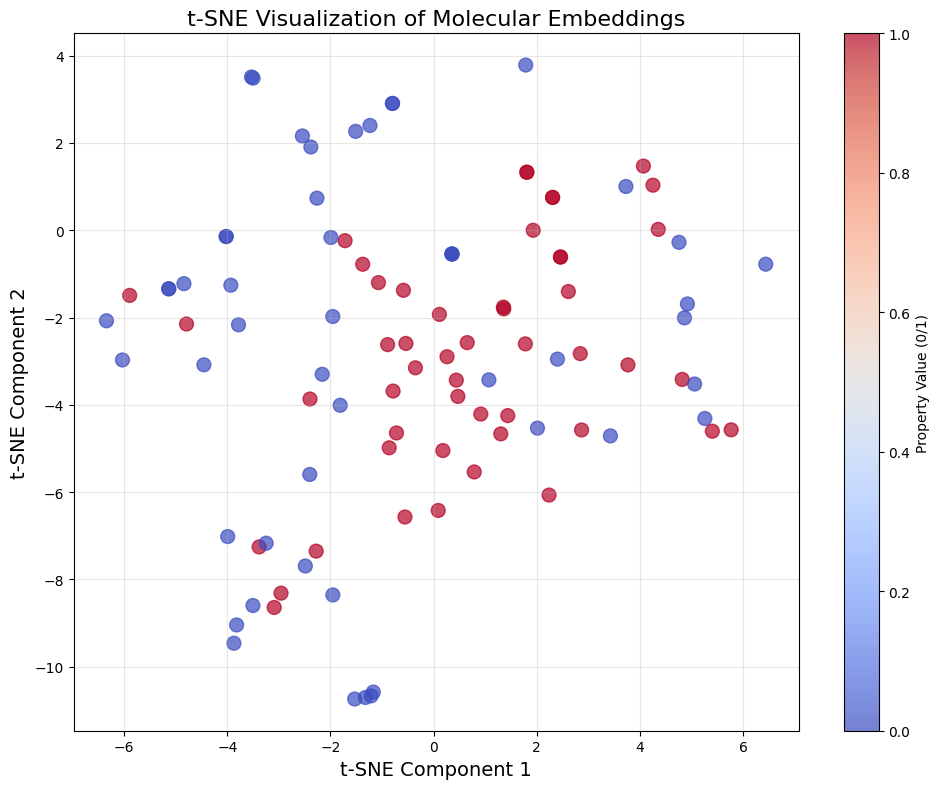

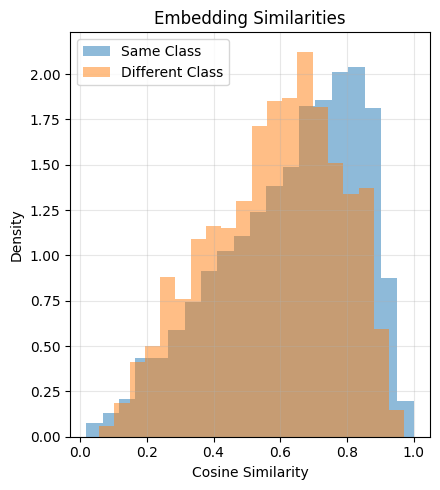

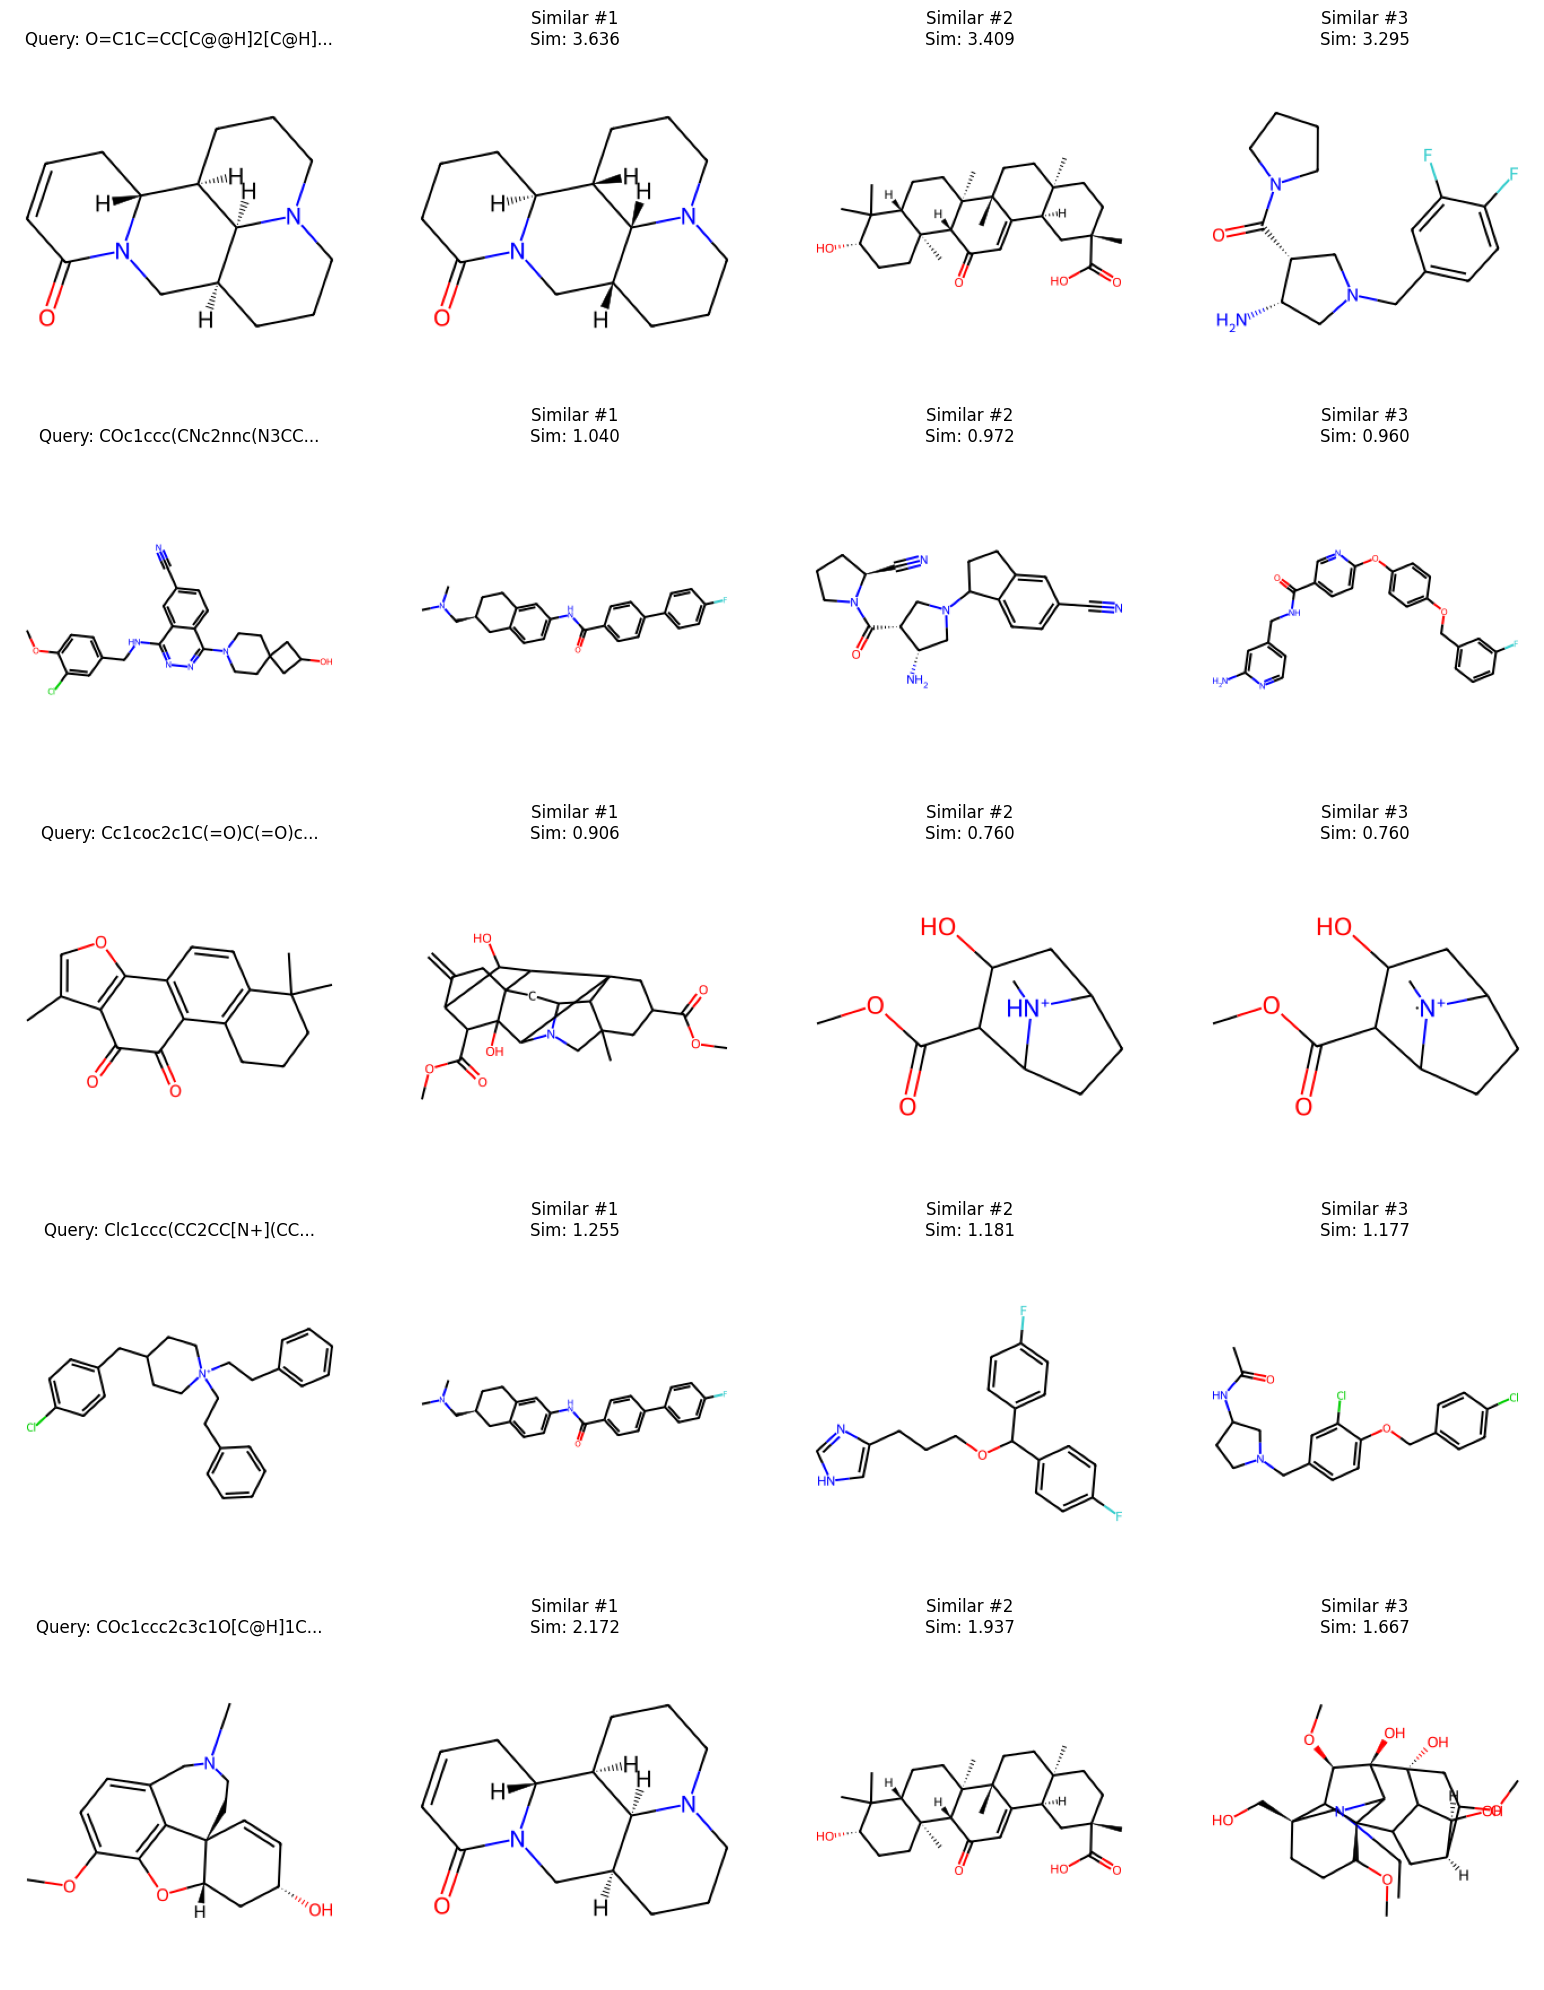

In [14]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def generate_molecule_embeddings(model, dataset, device, batch_size=32):
    """Generate molecular embeddings using the trained GIN model"""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    embeddings = []
    labels = []
    smiles_list = []

    with torch.no_grad():
        for data in loader:
            try:
                data = data.to(device)
                node_embeddings = model.get_embeddings(data.x.float(), data.edge_index, data.batch)
                last_layer_embedding = global_mean_pool(node_embeddings[-1], data.batch)

                embeddings.append(last_layer_embedding.cpu().numpy())
                labels.append(data.y.cpu().numpy())

                if hasattr(data, 'smiles'):
                    smiles_list.extend(data.smiles)
                
                del data
                torch.cuda.empty_cache()  # If using CUDA
            except Exception as e:
                print(f"Error processing batch: {str(e)}")
                continue

    if not embeddings:
        raise ValueError("No embeddings were generated")

    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    return embeddings, labels, smiles_list

# Generate embeddings using the trained GIN model
gin_model = models['GCN']
gin_embeddings, gin_labels, _ = generate_molecule_embeddings(gin_model, test_dataset, device)

#Visualize the embeddings using t-SNE
def visualize_molecular_embeddings(embeddings, labels):
    """Visualize molecular embeddings using t-SNE"""
    # Reduce embedding dimensionality for visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create scatter plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                        c=labels.squeeze(), cmap='coolwarm', alpha=0.7, s=100)

    plt.colorbar(scatter, label='Property Value (0/1)')
    plt.title('t-SNE Visualization of Molecular Embeddings', fontsize=16)
    plt.xlabel('t-SNE Component 1', fontsize=14)
    plt.ylabel('t-SNE Component 2', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Visualize the GIN embeddings
visualize_molecular_embeddings(gin_embeddings, gin_labels)

# Compare with embeddings from other models
gcn_model = models['GCN']
#gat_model = models['GAT']

gcn_embeddings, gcn_labels, _ = generate_molecule_embeddings(gcn_model, test_dataset, device)
#gat_embeddings, gat_labels, _ = generate_molecule_embeddings(gat_model, test_dataset, device)


# Calculate embedding similarity
def calculate_similarity_matrix(embeddings, normalize=True):
    """Calculate cosine similarity matrix between embeddings"""
    # Normalize if requested
    if normalize:
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings = embeddings / norms

    # Calculate cosine similarity
    similarity_matrix = np.dot(embeddings, embeddings.T)
    return similarity_matrix

# Compare similarity distributions
plt.figure(figsize=(12, 5))

# Process each model's embeddings
models_data = [
    ('GCN', gcn_embeddings)
    #('GAT', gat_embeddings)
    #('GIN', gin_embeddings)
]

for i, (name, embeddings) in enumerate(models_data):
    plt.subplot(1, 3, i+1)

    # Split by class
    class_0_idx = np.where(gin_labels.squeeze() < 0.5)[0]
    class_1_idx = np.where(gin_labels.squeeze() >= 0.5)[0]

    # Calculate similarity matrices
    sim_matrix = calculate_similarity_matrix(embeddings)

    # Extract similarities between same class and different class
    same_class_sim = []
    diff_class_sim = []

    for j in range(len(embeddings)):
        for k in range(j+1, len(embeddings)):
            if (j in class_0_idx and k in class_0_idx) or (j in class_1_idx and k in class_1_idx):
                same_class_sim.append(sim_matrix[j, k])
            else:
                diff_class_sim.append(sim_matrix[j, k])

    # Plot distributions
    plt.hist(same_class_sim, bins=20, alpha=0.5, label='Same Class', density=True)
    plt.hist(diff_class_sim, bins=20, alpha=0.5, label='Different Class', density=True)

    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.title('Embedding Similarities')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


def visualize_molecular_similarity(test_dataset, model, device, num_molecules=5, top_k=3):
    """Visualize molecular similarities based on GCN embeddings"""
    model.eval()

    try:
        subset_indices = np.random.choice(len(test_dataset), num_molecules, replace=False)
        query_molecules = [test_dataset[i] for i in subset_indices]

        all_embeddings, _, all_smiles = generate_molecule_embeddings(model, test_dataset, device)

        fig, axes = plt.subplots(num_molecules, top_k + 1, figsize=(4 * (top_k + 1), 4 * num_molecules))

        for i, query_mol in enumerate(query_molecules):
            try:
                query_data = query_mol.to(device)
                with torch.no_grad():
                    # Remove the unsqueeze operations that were adding extra dimensions
                    node_embeddings = model.get_embeddings(
                        query_data.x.float(),  # No need for unsqueeze
                        query_data.edge_index,  # No need for unsqueeze
                        torch.zeros(query_data.x.size(0), dtype=torch.long, device=device)
                    )
                    query_embedding = global_mean_pool(
                        node_embeddings[-1],
                        torch.zeros(query_data.x.size(0), dtype=torch.long, device=device)
                    )
                    query_embedding = query_embedding.cpu().numpy()

                similarities = np.dot(all_embeddings, query_embedding.T).squeeze()
                sorted_indices = np.argsort(similarities)[::-1]

                if hasattr(query_mol, 'smiles'):
                    query_idx = all_smiles.index(query_mol.smiles) if query_mol.smiles in all_smiles else -1
                    if query_idx >= 0 and query_idx in sorted_indices:
                        sorted_indices = np.delete(sorted_indices, np.where(sorted_indices == query_idx))

                top_k_indices = sorted_indices[:top_k]

                if hasattr(query_mol, 'smiles'):
                    try:
                        mol = Chem.MolFromSmiles(query_mol.smiles)
                        if mol is not None:
                            drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
                            drawer.DrawMolecule(mol)
                            drawer.FinishDrawing()
                            img = drawer.GetDrawingText()
                            query_img = Image.open(io.BytesIO(img))
                            axes[i, 0].imshow(query_img)
                            axes[i, 0].set_title(f"Query: {query_mol.smiles[:20]}...")
                            axes[i, 0].axis('off')

                            for j, idx in enumerate(top_k_indices):
                                if idx < len(test_dataset) and hasattr(test_dataset[idx], 'smiles'):
                                    similar_smiles = test_dataset[idx].smiles
                                    similar_mol = Chem.MolFromSmiles(similar_smiles)
                                    if similar_mol:
                                        drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
                                        drawer.DrawMolecule(similar_mol)
                                        drawer.FinishDrawing()
                                        img = drawer.GetDrawingText()
                                        similar_img = Image.open(io.BytesIO(img))
                                        axes[i, j+1].imshow(similar_img)
                                        axes[i, j+1].set_title(f"Similar #{j+1}\nSim: {similarities[idx]:.3f}")
                                        axes[i, j+1].axis('off')
                    except Exception as e:
                        print(f"Error processing molecule {i}: {str(e)}")
                        continue

            except Exception as e:
                print(f"Error processing query molecule {i}: {str(e)}")
                continue

        plt.tight_layout()
        plt.show()
        plt.close()
    except Exception as e:
        print(f"Error in visualization: {str(e)}")

# Visualize molecular similarities for the GIN model
visualize_molecular_similarity(test_dataset, models["GCN"], device)

Featurizing data: 100%|█████████████████████████| 1/1 [00:00<00:00, 1290.56it/s]


Data(x=[20, 22], edge_index=[2, 40], edge_attr=[40, 6], y=1.0, smiles='CC(C)(C)CC(C1=CC=CC=C1)C(O)CN(C)C(C)C')
torch.Size([20, 22])


Featurizing data: 100%|█████████████████████████| 1/1 [00:00<00:00, 1034.86it/s]


Data(x=[21, 22], edge_index=[2, 46], edge_attr=[46, 6], y=1.0, smiles='CN(C)CCCN1c2ccccc2Sc2ccc(Cl)cc21')
torch.Size([21, 22])


Featurizing data: 100%|██████████████████████████| 1/1 [00:00<00:00, 765.38it/s]


...

Featurizing data: 100%|█████████████████████████| 1/1 [00:00<00:00, 1419.39it/s]


Data(x=[20, 22], edge_index=[2, 42], edge_attr=[42, 6], y=1.0, smiles='CCN(CC)CCN1C(=O)C2=CC=CC=C2C(=O)N1C')
torch.Size([20, 22])


Featurizing data: 100%|█████████████████████████| 1/1 [00:00<00:00, 1183.49it/s]


Data(x=[25, 22], edge_index=[2, 52], edge_attr=[52, 6], y=1.0, smiles='CC(C)NCC(O)COC1=CC=C(C=C1)C2=CC(=C(C=C2I)I)OC')
torch.Size([25, 22])


Featurizing data: 100%|█████████████████████████| 1/1 [00:00<00:00, 1074.64it/s]


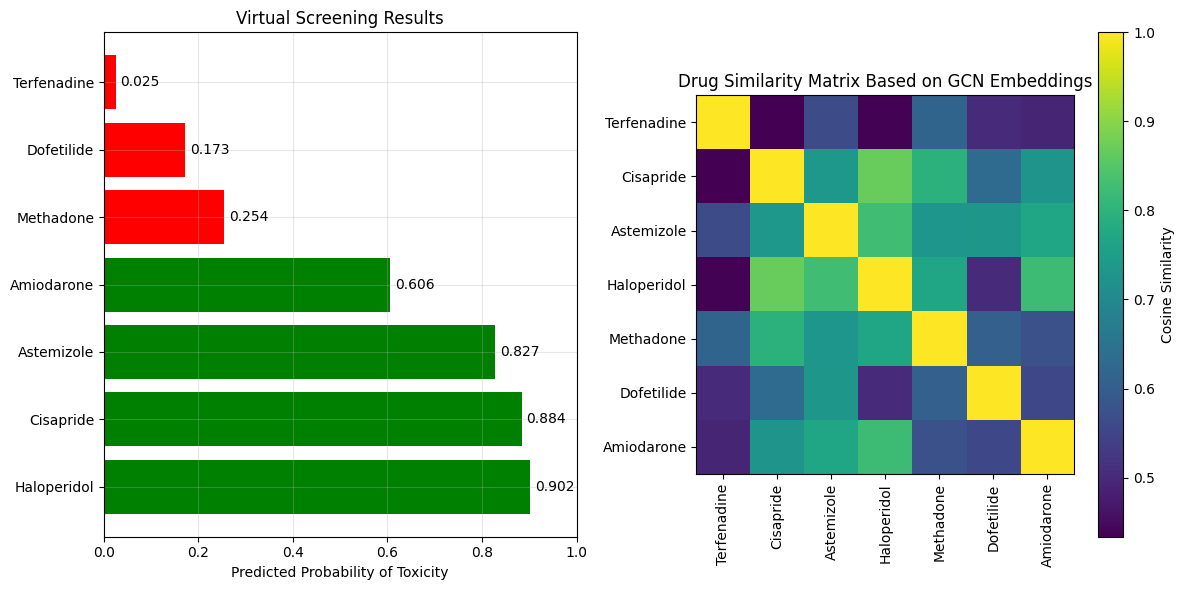

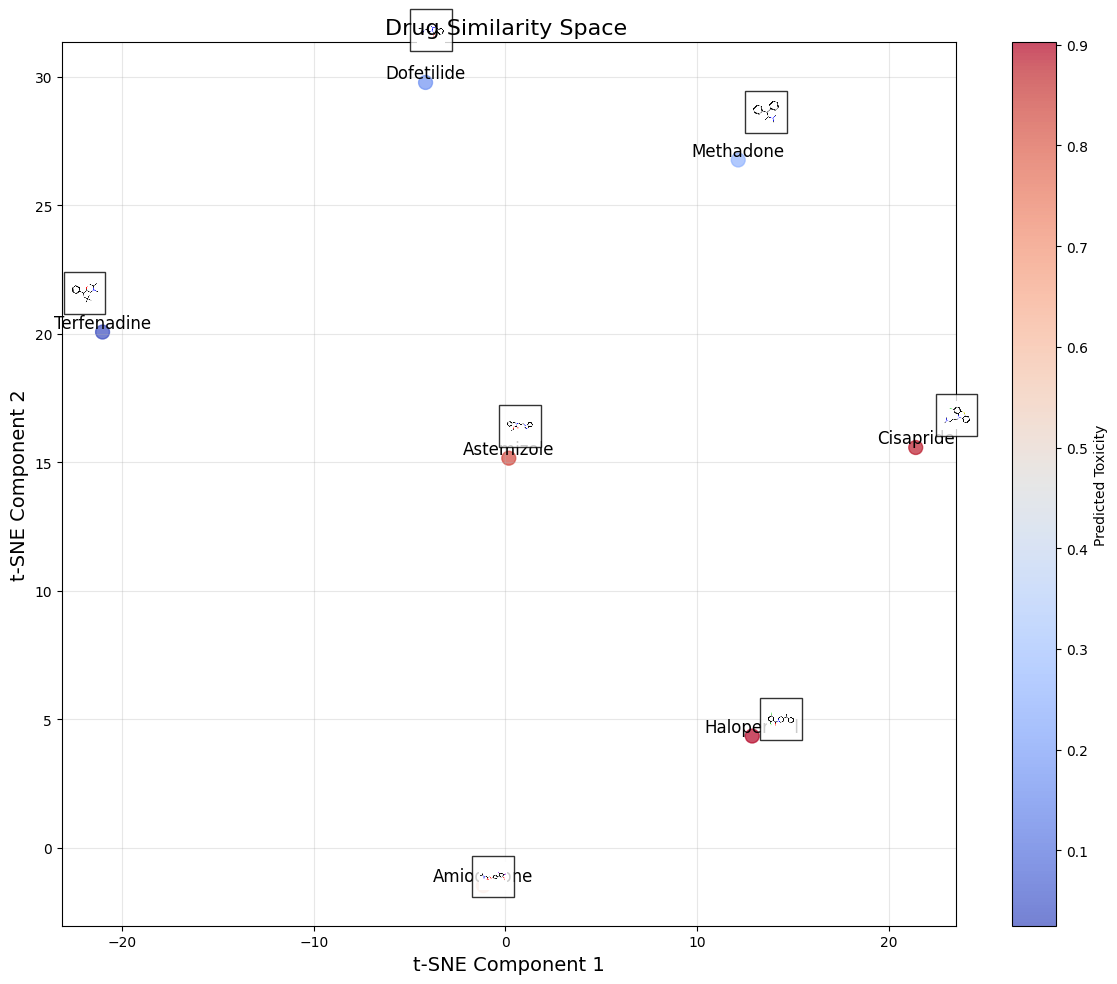

In [12]:
def virtual_screening_demo():
    """Demonstrate a simple virtual screening workflow using GIN"""
    # Load a small library of drug-like molecules

    
    drug_smiles = [
        "CC(C)(C)CC(C1=CC=CC=C1)C(O)CN(C)C(C)C",  # Terfenadine (safe by deeppk)
        "CN(C)CCCN1c2ccccc2Sc2ccc(Cl)cc21",      # Cisapride  ((toxic by deeppk)
        "CCOC(=O)N(CCCN1C=NC2=CC=CC=C21)CC3=CC=CC=C3",  # Astemizole
        "CC(C1=CC=CC=C1)C2CCN(CC2)C(=O)C3=CC(Cl)=CC=C3Cl",  # Haloperidol
        "CN(C)C(C)C(C1=CC=CC=C1)C2=CC=CC=C2", # Methadone
        "CCN(CC)CCN1C(=O)C2=CC=CC=C2C(=O)N1C", # Dofetilide
        "CC(C)NCC(O)COC1=CC=C(C=C1)C2=CC(=C(C=C2I)I)OC", # Amiodarone
        #"CCOC(=O)N1CCN(CC1)C2=NC3=CC=CC=C3NC2=O", # Zopiclone
        #"CC1=C(C(=O)N(N1C)C2=CC=CC=C2)C3=CC=CC=C3", # Antipyrine
        #"CN1C2=C(C(=O)N(C1=O)C)NC=N2"   # Theophylline
    ]

    drug_names = [
        "Terfenadine", "Cisapride", "Astemizole", "Haloperidol",
        "Methadone", "Dofetilide", "Amiodarone"
    ]

    # Generate embeddings for each drug
    gin_model.eval()
    embeddings = []
    valid_indices = []

    for i, smiles in enumerate(drug_smiles):
        #print(smiles)
        mol = Chem.MolFromSmiles(smiles)
        #print(mol)
        if mol is None:
            continue
        data = featurize_data_in_batches([smiles], [1.0], 1)[0]

        print(data)        
            
        data = data.to(device)
        #print(data.x)
        #print(data.x.shape)

        with torch.no_grad():
            print(data.x.shape)
            node_embeddings = gin_model.get_embeddings(data.x, data.edge_index,
                                                   torch.zeros(data.x.size(0), dtype=torch.long, device=device))
            graph_embedding = global_mean_pool(node_embeddings[-1],
                                           torch.zeros(data.x.size(0), dtype=torch.long, device=device))

        embeddings.append(graph_embedding.cpu().numpy())
        valid_indices.append(i)

    if embeddings:
        embeddings = np.vstack(embeddings)
        valid_drug_names = [drug_names[i] for i in valid_indices]
        valid_drug_smiles = [drug_smiles[i] for i in valid_indices]

        # Predict BBB permeability for each drug
        predictions = []

        for i, smiles in enumerate(valid_drug_smiles):
            data = featurize_data_in_batches([smiles], [1.0], 1)[0].to(device)

            with torch.no_grad():
                out = gin_model(data.x, data.edge_index, torch.zeros(data.x.size(0), dtype=torch.long, device=device))
                prob = torch.sigmoid(out).item()
                predictions.append(prob)

        # Visualize results
        plt.figure(figsize=(12, 6))

        # Sort by predicted probability
        sorted_indices = np.argsort(predictions)[::-1]
        sorted_names = [valid_drug_names[i] for i in sorted_indices]
        sorted_probs = [predictions[i] for i in sorted_indices]

        # Plot predictions
        plt.subplot(1, 2, 1)
        bars = plt.barh(sorted_names, sorted_probs, color=['green' if p > 0.5 else 'red' for p in sorted_probs])
        plt.xlabel('Predicted Probability of Toxicity')
        plt.title('Virtual Screening Results')
        plt.xlim(0, 1)
        plt.grid(True, alpha=0.3)

        # Add values
        for i, bar in enumerate(bars):
            plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{sorted_probs[i]:.3f}', va='center')

        # Calculate similarity matrix
        similarity_matrix = np.zeros((len(embeddings), len(embeddings)))
        for i in range(len(embeddings)):
            for j in range(len(embeddings)):
                similarity_matrix[i, j] = np.dot(embeddings[i], embeddings[j]) / (
                    np.linalg.norm(embeddings[i]) * np.linalg.norm(embeddings[j]))

        # Plot similarity matrix
        plt.subplot(1, 2, 2)
        im = plt.imshow(similarity_matrix, cmap='viridis')
        plt.colorbar(im, label='Cosine Similarity')
        plt.title('Drug Similarity Matrix Based on GCN Embeddings')
        plt.xticks(range(len(valid_drug_names)), valid_drug_names, rotation=90)
        plt.yticks(range(len(valid_drug_names)), valid_drug_names)

        plt.tight_layout()
        plt.savefig('Case Study1.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Visualize molecules clustered by similarity
        # Reduce dimensionality for visualization
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(embeddings)-1))
        embeddings_2d = tsne.fit_transform(embeddings)

        plt.figure(figsize=(12, 10))

        # Plot embeddings
        scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                           c=predictions, cmap='coolwarm', s=100, alpha=0.7)
        plt.colorbar(scatter, label='Predicted Toxicity')

        # Add drug names as labels
        for i, name in enumerate(valid_drug_names):
            plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1], name, fontsize=12,
                   ha='center', va='bottom')

            # Add molecule images
            mol = Chem.MolFromSmiles(valid_drug_smiles[i])

            if mol:
                img = Draw.MolToImage(mol, size=(100, 100))
                imagebox = OffsetImage(img, zoom=0.2)
                ab = AnnotationBbox(imagebox, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                                  xycoords='data', boxcoords="offset points",
                                  box_alignment=(0.1, 0.1), pad=0.5,
                                  bboxprops=dict(facecolor='white', alpha=0.8))
                plt.gca().add_artist(ab)

        plt.title('Drug Similarity Space ',fontsize=16)
        plt.xlabel('t-SNE Component 1', fontsize=14)
        plt.ylabel('t-SNE Component 2', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('Case Study.png', dpi=300, bbox_inches='tight')
        plt.show()

# Demonstrate virtual screening application
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
virtual_screening_demo()